# Aim 2: Identifying At-Risk TB Contacts

**Goal**: Identify contacts of index-TB cases at risk of developing household TB disease, and predict contacts resistant to TB infection despite persistent exposure.

**Target Proxy**: Symptom presence (contacts with cough, fever, weight loss, etc. are labeled 'at-risk').

**Approach**:
- Binary classification on healthy contacts data
- Target: `TARGET_SYMPTOM_PRESENT` (1 = symptomatic/at-risk, 0 = asymptomatic/resistant)
- Models: Logistic Regression, Random Forest, XGBoost

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.feature_engineering import prepare_aim2_data
from src.models.train import train_models, get_champion_model
from src.models.evaluate import evaluate_model
from src.data.clean_data import build_aim2_dataset
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
%matplotlib inline


---
## 1. Data Overview

Total contacts: 46
Columns: ['STUDY_ID', 'CONTACT_NUMBER', 'STUDY SITE', 'DATE', 'INITIALS', 'AGE', 'SEX', 'WEIGHT', 'TEMPERATURE', 'COUGH', 'COUGH_WEEKS', 'FEVER', 'FEVER_WEEKS', 'WEIGHT LOSS', 'WEIGHT_LOSS_WEEKS', 'NIGHT SWEATS', 'NIGHT_SWEATS_WEEKS', 'DYSPNEA', 'DYSPNEA_WEEKS', 'CHEST PAIN', 'CHEST_PAIN_WEEKS', 'HEMOPTYSIS', 'HEMOPTYSIS_WEEKS', 'OTHER_SYMPTOMS', 'HIV STATUS', 'ON ART', 'COUGH_BINARY', 'FEVER_BINARY', 'WEIGHT LOSS_BINARY', 'NIGHT SWEATS_BINARY', 'DYSPNEA_BINARY', 'CHEST PAIN_BINARY', 'HEMOPTYSIS_BINARY', 'TARGET_SYMPTOM_PRESENT']

Target distribution:
TARGET_SYMPTOM_PRESENT
0    36
1    10
Name: count, dtype: int64

Symptomatic (at-risk): 10
Asymptomatic (resistant): 36


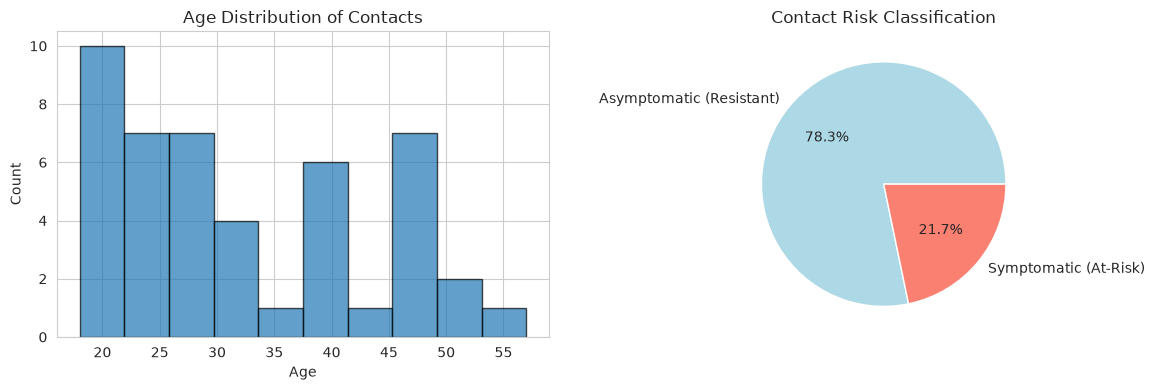

In [2]:
df = build_aim2_dataset()
print(f"Total contacts: {len(df)}")
print(f"Columns: {list(df.columns)}")
print("\nTarget distribution:")
print(df['TARGET_SYMPTOM_PRESENT'].value_counts())
print(f"\nSymptomatic (at-risk): {df['TARGET_SYMPTOM_PRESENT'].sum()}")
print(f"Asymptomatic (resistant): {(df['TARGET_SYMPTOM_PRESENT'] == 0).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age distribution
axes[0].hist(df['AGE'].dropna(), bins=10, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution of Contacts')

# Target pie
target_counts = df['TARGET_SYMPTOM_PRESENT'].value_counts()
axes[1].pie(target_counts.values, labels=['Asymptomatic (Resistant)', 'Symptomatic (At-Risk)'],
            autopct='%1.1f%%', colors=['lightblue', 'salmon'])
axes[1].set_title('Contact Risk Classification')

plt.tight_layout()
plt.show()

---
## 2. Prepare Data for Modeling

In [3]:
X_train, X_test, y_train, y_test, preprocessor, feature_cols = prepare_aim2_data(
    test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Features: {feature_cols}")
print("\nClass distribution (train):")
print(y_train.value_counts() if len(y_train) > 0 else "No training data")

if len(X_train) > 0:
    print("\nSample of training data:")
    display(X_train.head())

Training samples: 36
Test samples: 10
Features: ['AGE', 'SEX', 'WEIGHT', 'TEMPERATURE', 'COUGH', 'FEVER', 'WEIGHT LOSS', 'NIGHT SWEATS', 'DYSPNEA', 'CHEST PAIN', 'HEMOPTYSIS', 'HIV STATUS']

Class distribution (train):
TARGET_SYMPTOM_PRESENT
0    28
1     8
Name: count, dtype: int64

Sample of training data:


,AGE,SEX,WEIGHT,TEMPERATURE,COUGH,FEVER,WEIGHT LOSS,NIGHT SWEATS,DYSPNEA,CHEST PAIN,HEMOPTYSIS,HIV STATUS
16,53,F,89.0,37.1,NO,NO,NO,NO,NO,NO,NO,NO
2,18,M,51.0,36.8,NO,NO,NO,NO,NO,NO,NO,NO
0,18,M,48.0,37.2,NO,NO,NO,NO,NO,NO,NO,NO
36,57,F,65.0,37.0,YES,NO,YES,YES,NO,NO,NO,NO
17,28,M,66.0,36.0,NO,NO,NO,NO,NO,NO,NO,NO


---
## 3. Train Models

In [4]:
if len(X_train) >= 3:
    results, trained = train_models(
        X_train, y_train, preprocessor, feature_cols,
        aim="aim2_contact_risk",
        use_smote=(y_train.sum() > 0 and y_train.sum() < len(y_train)),
        cv_folds=min(5, len(X_train)),
        random_state=42,
    )
    
    print("\n=== Model Performance ===")
    summary = pd.DataFrame([
        {
            'Model': name,
            'Version': meta['version'],
            'Train AUC': f"{meta['train_auc']:.3f}",
            'CV AUC': f"{meta['cv_auc_mean']:.3f} ± {meta['cv_auc_std']:.3f}",
        }
        for name, meta in results.items()
    ])
    display(summary)
    
    if len(X_test) > 0:
        print("\n=== Test Set Evaluation ===")
        for name, (pipeline, _) in trained.items():
            evaluate_model(
                pipeline, X_test, y_test, name,
                "aim2_contact_risk", results[name]['version']
            )
else:
    print("Insufficient training samples.")

  logistic_regression (v34): CV AUC=1.000 ± 0.000, Train AUC=1.000


  random_forest (v35): CV AUC=1.000 ± 0.000, Train AUC=1.000


  xgboost (v36): CV AUC=1.000 ± 0.000, Train AUC=1.000

=== Model Performance ===


,Model,Version,Train AUC,CV AUC
0,logistic_regression,v34,1.000,1.000 ± 0.000
1,random_forest,v35,1.000,1.000 ± 0.000
2,xgboost,v36,1.000,1.000 ± 0.000



=== Test Set Evaluation ===
  logistic_regression (v34): Test AUC=1.000, F1=1.000, Recall=1.000


  random_forest (v35): Test AUC=1.000, F1=1.000, Recall=1.000


  xgboost (v36): Test AUC=1.000, F1=1.000, Recall=1.000


---
## 4. Detailed Symptom Analysis

Symptom breakdown among contacts:
  COUGH: 10 contacts (21.7%)
  FEVER: 1 contacts (2.2%)
  WEIGHT LOSS: 4 contacts (8.7%)
  NIGHT SWEATS: 2 contacts (4.3%)
  DYSPNEA: 0 contacts (0.0%)
  CHEST PAIN: 1 contacts (2.2%)
  HEMOPTYSIS: 0 contacts (0.0%)


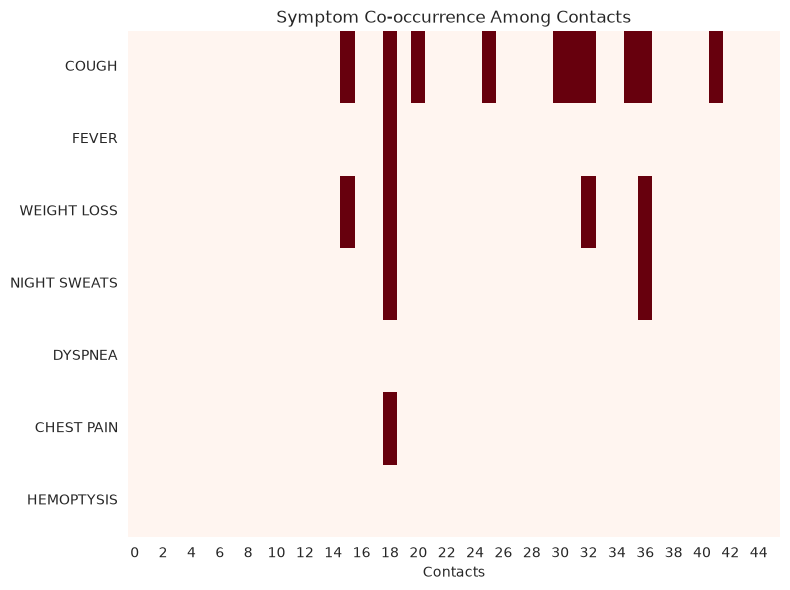


Contacts with multiple symptoms: 4


In [5]:
symptom_cols = ['COUGH', 'FEVER', 'WEIGHT LOSS', 'NIGHT SWEATS', 'DYSPNEA', 'CHEST PAIN', 'HEMOPTYSIS']
available_symptoms = [c for c in symptom_cols if c in df.columns]

print("Symptom breakdown among contacts:")
for col in available_symptoms:
    counts = df[col].value_counts()
    yes = counts.get('YES', 0)
    print(f"  {col}: {yes} contacts ({yes/len(df)*100:.1f}%)")

# Create a symptom count matrix
binary_cols = [c + '_BINARY' for c in available_symptoms if c + '_BINARY' in df.columns]
if binary_cols:
    symptom_matrix = df[binary_cols]
    symptom_matrix.columns = available_symptoms
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(symptom_matrix.T, cmap='Reds', cbar=False, ax=ax)
    ax.set_xlabel('Contacts')
    ax.set_title('Symptom Co-occurrence Among Contacts')
    plt.tight_layout()
    plt.show()
    
    print(f"\nContacts with multiple symptoms: {(symptom_matrix.sum(axis=1) > 1).sum()}")

---
## 5. HIV Status Among Contacts

HIV Status vs Symptom Presence:


TARGET_SYMPTOM_PRESENT,0,1
HIV STATUS,,
NO,77.777778,22.222222


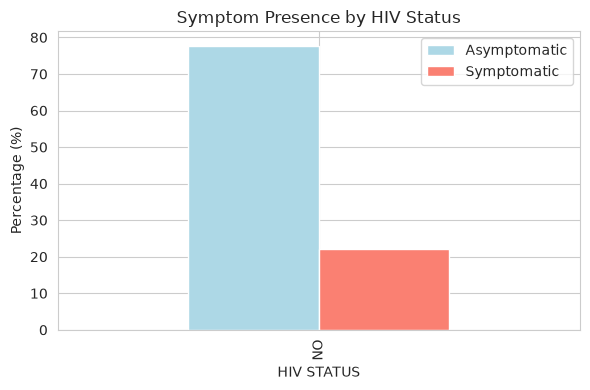

In [6]:
if 'HIV STATUS' in df.columns:
    hiv_symptom = pd.crosstab(df['HIV STATUS'], df['TARGET_SYMPTOM_PRESENT'], 
                               normalize='index') * 100
    print("HIV Status vs Symptom Presence:")
    display(hiv_symptom)
    
    fig, ax = plt.subplots(figsize=(6, 4))
    hiv_symptom.plot(kind='bar', ax=ax, color=['lightblue', 'salmon'])
    ax.set_ylabel('Percentage (%)')
    ax.set_title('Symptom Presence by HIV Status')
    ax.legend(['Asymptomatic', 'Symptomatic'])
    plt.tight_layout()
    plt.show()

---
## 6. Conclusions

In [7]:
print("=== AIM 2 Summary ===")
print(f"\nData: {len(X_train)} training, {len(X_test)} test samples")
print(f"Features used: {len(feature_cols)}")

if len(X_train) >= 3:
    champion = get_champion_model('aim2_contact_risk')
    if champion:
        print(f"Champion model: {champion['model']} (v{champion['version']})")
        print(f"CV AUC: {champion['cv_auc_mean']:.3f} ± {champion['cv_auc_std']:.3f}")

print("\nLimitations:")
print("1. Proxy target (symptom presence) not validated against actual TB development")
print(f"2. Small sample size ({len(df)} contacts)")
print("3. No longitudinal outcome data for contacts")
print("\nRecommendations:")
print("1. Follow-up contacts longitudinally to confirm conversion to active TB")
print("2. Add household exposure intensity (e.g., smear-positive index case)")
print("3. Consider TST/IGRA results if available as more specific outcome")

=== AIM 2 Summary ===

Data: 36 training, 10 test samples
Features used: 12
Champion model: xgboost (vv15)
CV AUC: 1.000 ± 0.000

Limitations:
1. Proxy target (symptom presence) not validated against actual TB development
2. Small sample size (46 contacts)
3. No longitudinal outcome data for contacts

Recommendations:
1. Follow-up contacts longitudinally to confirm conversion to active TB
2. Add household exposure intensity (e.g., smear-positive index case)
3. Consider TST/IGRA results if available as more specific outcome
